# 🛒 Retail Transaction Data Analysis
### HMS Commercial — Data Science & Analytics Technical Test 2025

**Author:** Irfan Karim  
**Dataset:** Online Retail Transactions (2009–2011)  
**Objective:** Analyze sales data, forecast demand, and build a Customer 360 framework.

---

**Table of Contents:**
1. [Data Loading & Cleaning](#1-data-loading--cleaning)
2. [Exploratory Data Analysis & Sales Insights](#2-exploratory-data-analysis--sales-insights)
3. [Demand Forecasting (6 Months)](#3-demand-forecasting-6-months)
4. [Customer 360 Analysis](#4-customer-360-analysis)
5. [Summary & Recommendations](#5-summary--recommendations)

---
## 1. Data Loading & Cleaning <a id="1-data-loading--cleaning"></a>

### 1.1 Import Libraries

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Time Series
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             mean_absolute_error, mean_absolute_percentage_error,
                             silhouette_score)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


### 1.2 Load Dataset

In [2]:
# Load the dataset
df_raw = pd.read_csv('retail_transaction_data.csv')

print(f"Dataset Shape: {df_raw.shape}")
print(f"Rows: {df_raw.shape[0]:,} | Columns: {df_raw.shape[1]}")
print()
print("Column Info:")
print("-" * 60)
df_raw.info()

Dataset Shape: (1067371, 8)
Rows: 1,067,371 | Columns: 8

Column Info:
------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   order_id             1067371 non-null  object 
 1   product_id           1067371 non-null  object 
 2   product_description  1062989 non-null  object 
 3   quantity             1067371 non-null  int64  
 4   order_date           1067371 non-null  object 
 5   unit_price           1067371 non-null  float64
 6   customer_id          824364 non-null   float64
 7   country              1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [3]:
# Preview the data
df_raw.head(10)

,order_id,product_id,product_description,quantity,order_date,unit_price,customer_id,country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
5,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom
6,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
7,489434,21523,FANCY FONT HOME SWEET HOME DOORMAT,10,2009-12-01 07:45:00,5.95,13085.0,United Kingdom
8,489435,22350,CAT BOWL,12,2009-12-01 07:46:00,2.55,13085.0,United Kingdom
9,489435,22349,"DOG BOWL , CHASING BALL DESIGN",12,2009-12-01 07:46:00,3.75,13085.0,United Kingdom


### 1.3 Data Quality Assessment

In [4]:
# Check for missing values
missing = df_raw.isnull().sum()
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("=== Missing Values Summary ===")
print(missing_df)
print()

# Check for duplicates
dup_count = df_raw.duplicated().sum()
print(f"Duplicate rows: {dup_count:,} ({dup_count/len(df_raw)*100:.2f}%)")
print()

# Basic statistics
print("=== Numerical Summary ===")
df_raw.describe()

=== Missing Values Summary ===
                     Missing Count  Missing %
customer_id                 243007      22.77
product_description           4382       0.41

Duplicate rows: 34,335 (3.22%)

=== Numerical Summary ===


,quantity,unit_price,customer_id
count,1.067371e+06,1.067371e+06,824364.000000
mean,9.938898e+00,4.649388e+00,15324.638504
std,1.727058e+02,1.235531e+02,1697.464450
min,-8.099500e+04,-5.359436e+04,12346.000000
25%,1.000000e+00,1.250000e+00,13975.000000
50%,3.000000e+00,2.100000e+00,15255.000000
75%,1.000000e+01,4.150000e+00,16797.000000
max,8.099500e+04,3.897000e+04,18287.000000


In [5]:
# Identify cancelled orders (Order ID starts with 'C')
# First, ensure order_id is string
df_raw['order_id'] = df_raw['order_id'].astype(str)
cancelled_mask = df_raw['order_id'].str.startswith('C')
print(f"Total records: {len(df_raw):,}")
print(f"Cancelled orders: {cancelled_mask.sum():,} ({cancelled_mask.sum()/len(df_raw)*100:.2f}%)")
print(f"Valid orders: {(~cancelled_mask).sum():,} ({(~cancelled_mask).sum()/len(df_raw)*100:.2f}%)")

Total records: 1,067,371
Cancelled orders: 19,494 (1.83%)
Valid orders: 1,047,877 (98.17%)


### 1.4 Data Cleaning

**Cleaning Steps:**
1. Parse `order_date` to datetime
2. Remove records with missing `customer_id` (cannot link to customers)
3. Separate cancelled orders for analysis, keep valid orders for main analysis
4. Remove records with `unit_price` <= 0 (likely errors or adjustments)
5. Remove records with `quantity` <= 0 in the valid order set
6. Create `total_amount` = `quantity` × `unit_price`

In [6]:
# Step 1: Parse dates
df_raw['order_date'] = pd.to_datetime(df_raw['order_date'], format='mixed', dayfirst=True)

# Step 2: Separate cancelled orders for analysis
df_cancelled = df_raw[cancelled_mask].copy()
df = df_raw[~cancelled_mask].copy()
print(f"After removing cancelled orders: {len(df):,} rows")

# Step 3: Remove missing customer_id
before = len(df)
df = df.dropna(subset=['customer_id'])
print(f"After removing null customer_id: {len(df):,} rows (removed {before - len(df):,})")

# Step 4: Remove zero/negative unit_price
before = len(df)
df = df[df['unit_price'] > 0]
print(f"After removing unit_price <= 0: {len(df):,} rows (removed {before - len(df):,})")

# Step 5: Remove zero/negative quantity
before = len(df)
df = df[df['quantity'] > 0]
print(f"After removing quantity <= 0: {len(df):,} rows (removed {before - len(df):,})")

# Step 6: Remove duplicates
before = len(df)
df = df.drop_duplicates()
print(f"After removing duplicates: {len(df):,} rows (removed {before - len(df):,})")

# Step 7: Create total_amount
df['total_amount'] = df['quantity'] * df['unit_price']

# Step 8: Extract time features
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['year_month'] = df['order_date'].dt.to_period('M')
df['day_of_week'] = df['order_date'].dt.day_name()
df['hour'] = df['order_date'].dt.hour

# Convert customer_id to int
df['customer_id'] = df['customer_id'].astype(int)

print(f"\n✅ Final cleaned dataset: {len(df):,} rows × {df.shape[1]} columns")
print(f"Date range: {df['order_date'].min()} to {df['order_date'].max()}")
df.head()

After removing cancelled orders: 1,047,877 rows
After removing null customer_id: 805,620 rows (removed 242,257)
After removing unit_price <= 0: 805,549 rows (removed 71)
After removing quantity <= 0: 805,549 rows (removed 0)
After removing duplicates: 779,425 rows (removed 26,124)

✅ Final cleaned dataset: 779,425 rows × 14 columns
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


,order_id,product_id,product_description,quantity,order_date,unit_price,customer_id,country,total_amount,year,month,year_month,day_of_week,hour
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,2009-12,Tuesday,7
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday,7
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday,7
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8,2009,12,2009-12,Tuesday,7
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0,2009,12,2009-12,Tuesday,7


---
## 2. Exploratory Data Analysis & Sales Insights <a id="2-exploratory-data-analysis--sales-insights"></a>

### 2.1 Overall Sales Performance

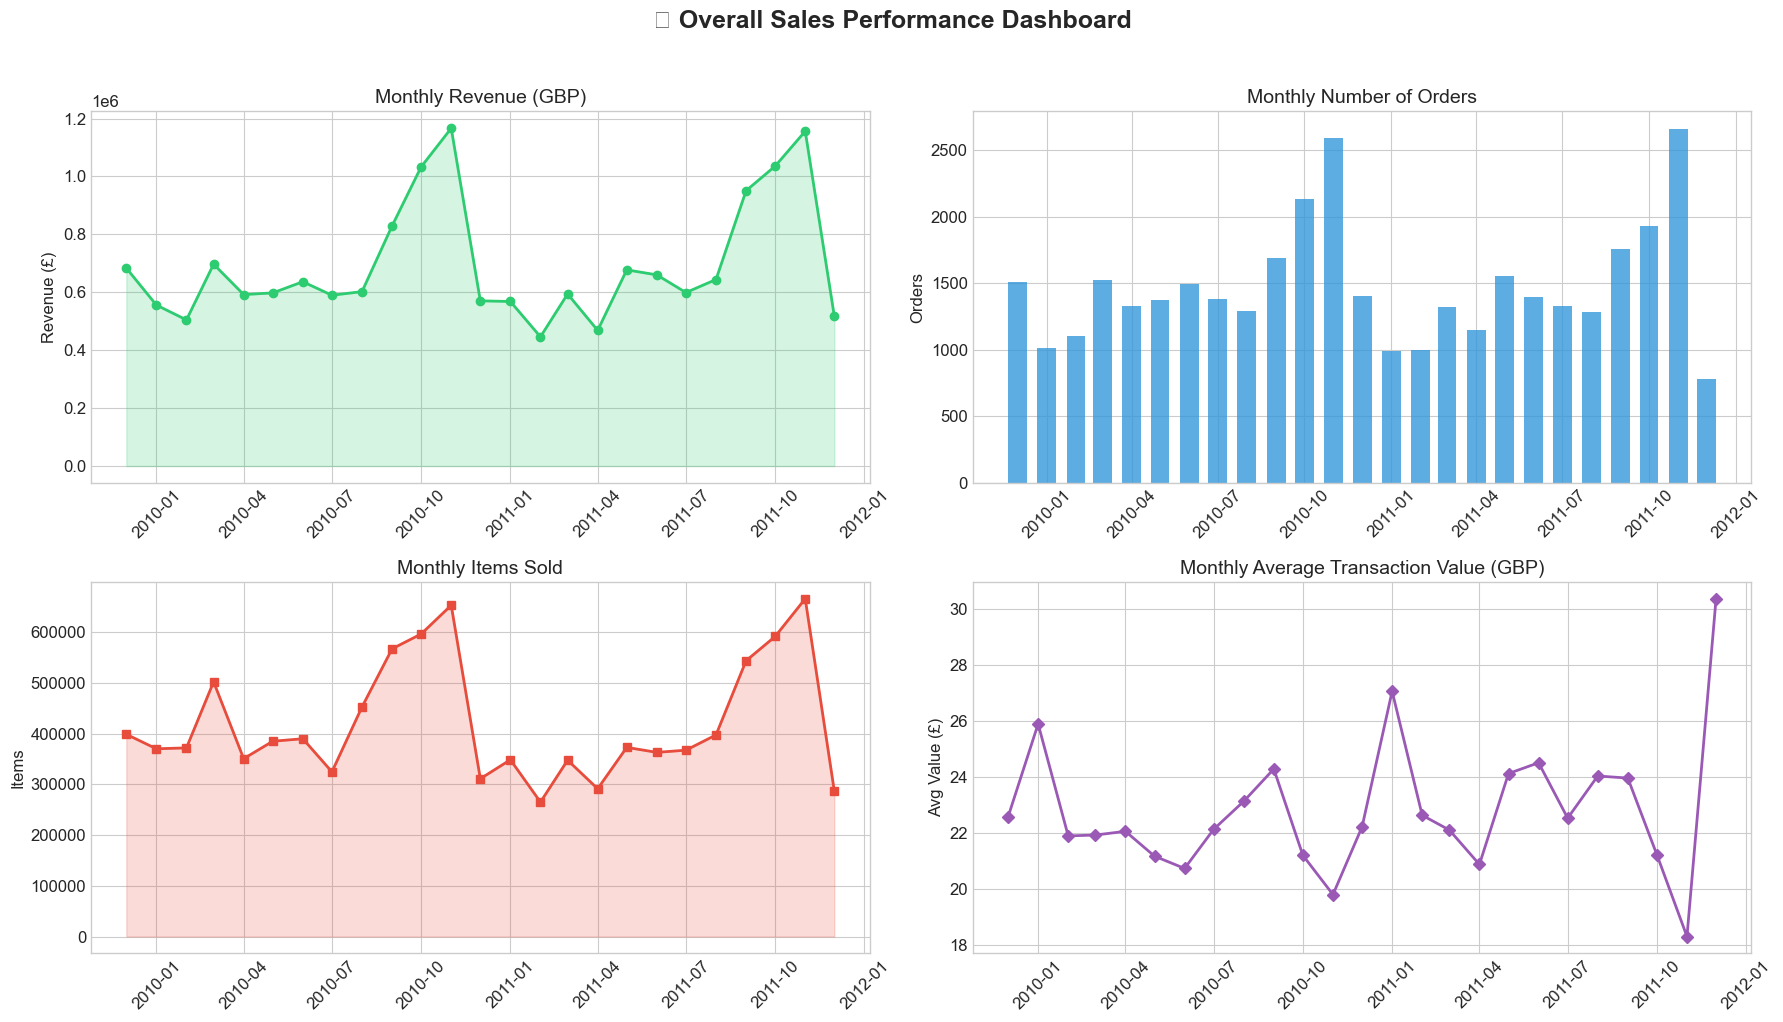

📋 KEY PERFORMANCE INDICATORS
Total Revenue:       £17,374,804.27
Total Orders:        36,969
Total Items Sold:    10,513,952
Avg Order Value:     £469.98
Unique Customers:    5,878
Unique Products:     4,631
Countries Served:    41


In [7]:
# Monthly Revenue & Order Volume
monthly_sales = df.groupby('year_month').agg(
    revenue=('total_amount', 'sum'),
    orders=('order_id', 'nunique'),
    items_sold=('quantity', 'sum'),
    avg_order_value=('total_amount', 'mean')
).reset_index()
monthly_sales['year_month_dt'] = monthly_sales['year_month'].dt.to_timestamp()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('📊 Overall Sales Performance Dashboard', fontsize=18, fontweight='bold', y=1.02)

# Revenue Trend
axes[0,0].plot(monthly_sales['year_month_dt'], monthly_sales['revenue'], 'o-', color='#2ecc71', linewidth=2, markersize=6)
axes[0,0].fill_between(monthly_sales['year_month_dt'], monthly_sales['revenue'], alpha=0.2, color='#2ecc71')
axes[0,0].set_title('Monthly Revenue (GBP)')
axes[0,0].set_ylabel('Revenue (£)')
axes[0,0].tick_params(axis='x', rotation=45)

# Order Volume Trend
axes[0,1].bar(monthly_sales['year_month_dt'], monthly_sales['orders'], color='#3498db', alpha=0.8, width=20)
axes[0,1].set_title('Monthly Number of Orders')
axes[0,1].set_ylabel('Orders')
axes[0,1].tick_params(axis='x', rotation=45)

# Items Sold Trend
axes[1,0].plot(monthly_sales['year_month_dt'], monthly_sales['items_sold'], 's-', color='#e74c3c', linewidth=2, markersize=6)
axes[1,0].fill_between(monthly_sales['year_month_dt'], monthly_sales['items_sold'], alpha=0.2, color='#e74c3c')
axes[1,0].set_title('Monthly Items Sold')
axes[1,0].set_ylabel('Items')
axes[1,0].tick_params(axis='x', rotation=45)

# Average Order Value
axes[1,1].plot(monthly_sales['year_month_dt'], monthly_sales['avg_order_value'], 'D-', color='#9b59b6', linewidth=2, markersize=6)
axes[1,1].set_title('Monthly Average Transaction Value (GBP)')
axes[1,1].set_ylabel('Avg Value (£)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary KPIs
print("=" * 60)
print("📋 KEY PERFORMANCE INDICATORS")
print("=" * 60)
print(f"Total Revenue:       £{df['total_amount'].sum():,.2f}")
print(f"Total Orders:        {df['order_id'].nunique():,}")
print(f"Total Items Sold:    {df['quantity'].sum():,}")
print(f"Avg Order Value:     £{df.groupby('order_id')['total_amount'].sum().mean():,.2f}")
print(f"Unique Customers:    {df['customer_id'].nunique():,}")
print(f"Unique Products:     {df['product_id'].nunique():,}")
print(f"Countries Served:    {df['country'].nunique()}")

### 2.2 Top Products Analysis

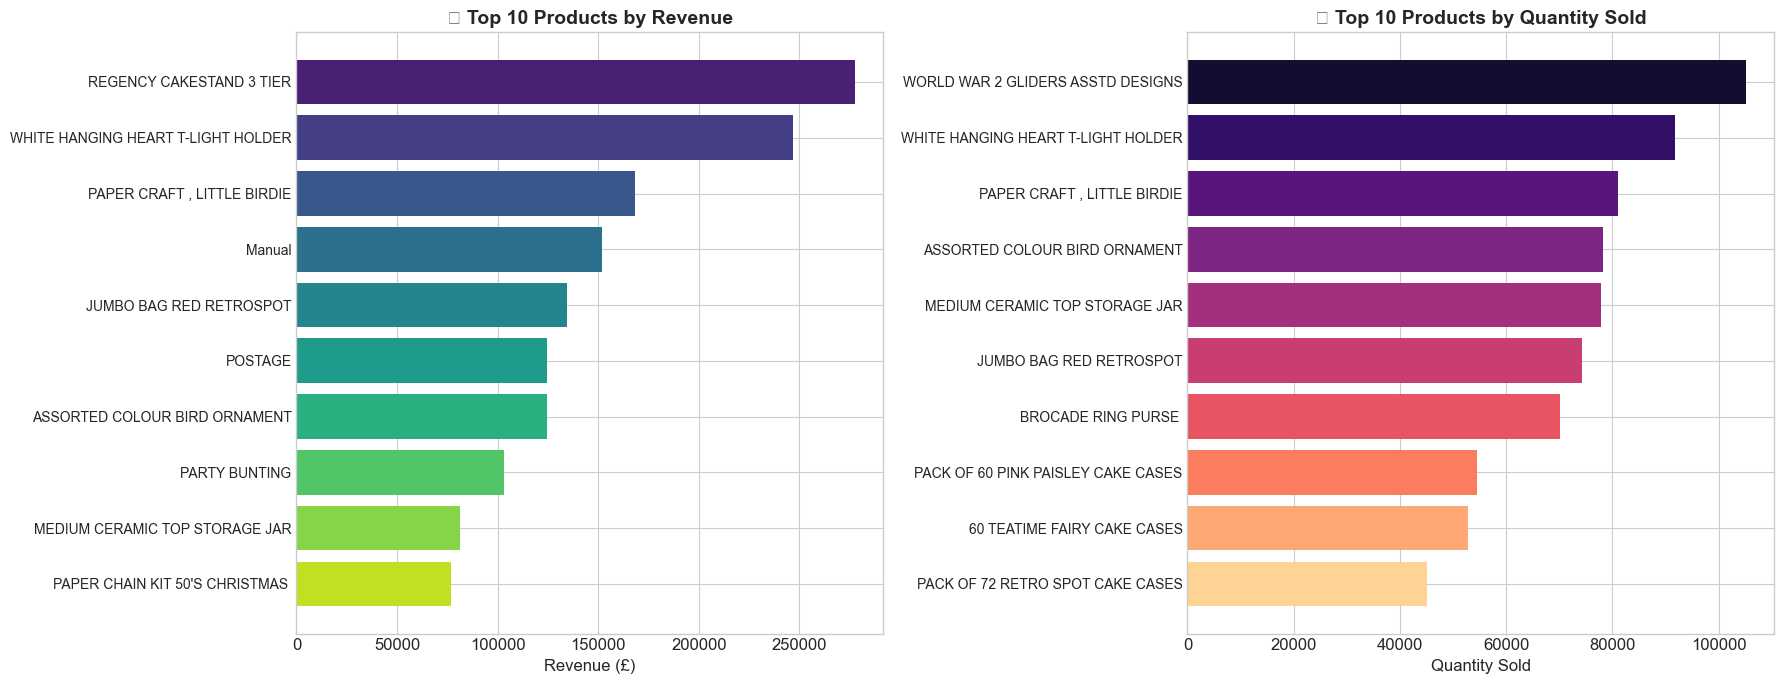


Top 10 Products by Revenue:
               product_description   revenue  qty_sold  num_orders
          REGENCY CAKESTAND 3 TIER 277656.25     24124        3317
WHITE HANGING HEART T-LIGHT HOLDER 247048.01     91757        4888
       PAPER CRAFT , LITTLE BIRDIE 168469.60     80995           1
                            Manual 151777.67      9384         620
           JUMBO BAG RED RETROSPOT 134307.44     74224        2612
                           POSTAGE 124648.04      5235        1803
     ASSORTED COLOUR BIRD ORNAMENT 124351.86     78234        2652
                     PARTY BUNTING 103283.38     23460        2077
    MEDIUM CERAMIC TOP STORAGE JAR  81416.73     77916         195
   PAPER CHAIN KIT 50'S CHRISTMAS   76598.18     28380        1691


In [8]:
# Top 10 Products by Revenue
top_products_rev = df.groupby(['product_id', 'product_description']).agg(
    revenue=('total_amount', 'sum'),
    qty_sold=('quantity', 'sum'),
    num_orders=('order_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# By Revenue
desc_labels_rev = [d[:35] + '...' if len(str(d)) > 35 else str(d) for d in top_products_rev['product_description']]
axes[0].barh(range(len(top_products_rev)), top_products_rev['revenue'], color=sns.color_palette('viridis', 10))
axes[0].set_yticks(range(len(top_products_rev)))
axes[0].set_yticklabels(desc_labels_rev, fontsize=10)
axes[0].set_xlabel('Revenue (£)')
axes[0].set_title('🏆 Top 10 Products by Revenue', fontsize=14, fontweight='bold')
axes[0].invert_yaxis()

# Top 10 Products by Quantity Sold
top_products_qty = df.groupby(['product_id', 'product_description']).agg(
    qty_sold=('quantity', 'sum')
).reset_index().sort_values('qty_sold', ascending=False).head(10)

desc_labels_qty = [d[:35] + '...' if len(str(d)) > 35 else str(d) for d in top_products_qty['product_description']]
axes[1].barh(range(len(top_products_qty)), top_products_qty['qty_sold'], color=sns.color_palette('magma', 10))
axes[1].set_yticks(range(len(top_products_qty)))
axes[1].set_yticklabels(desc_labels_qty, fontsize=10)
axes[1].set_xlabel('Quantity Sold')
axes[1].set_title('🏆 Top 10 Products by Quantity Sold', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTop 10 Products by Revenue:")
print(top_products_rev[['product_description', 'revenue', 'qty_sold', 'num_orders']].to_string(index=False))

### 2.3 Geographic Analysis

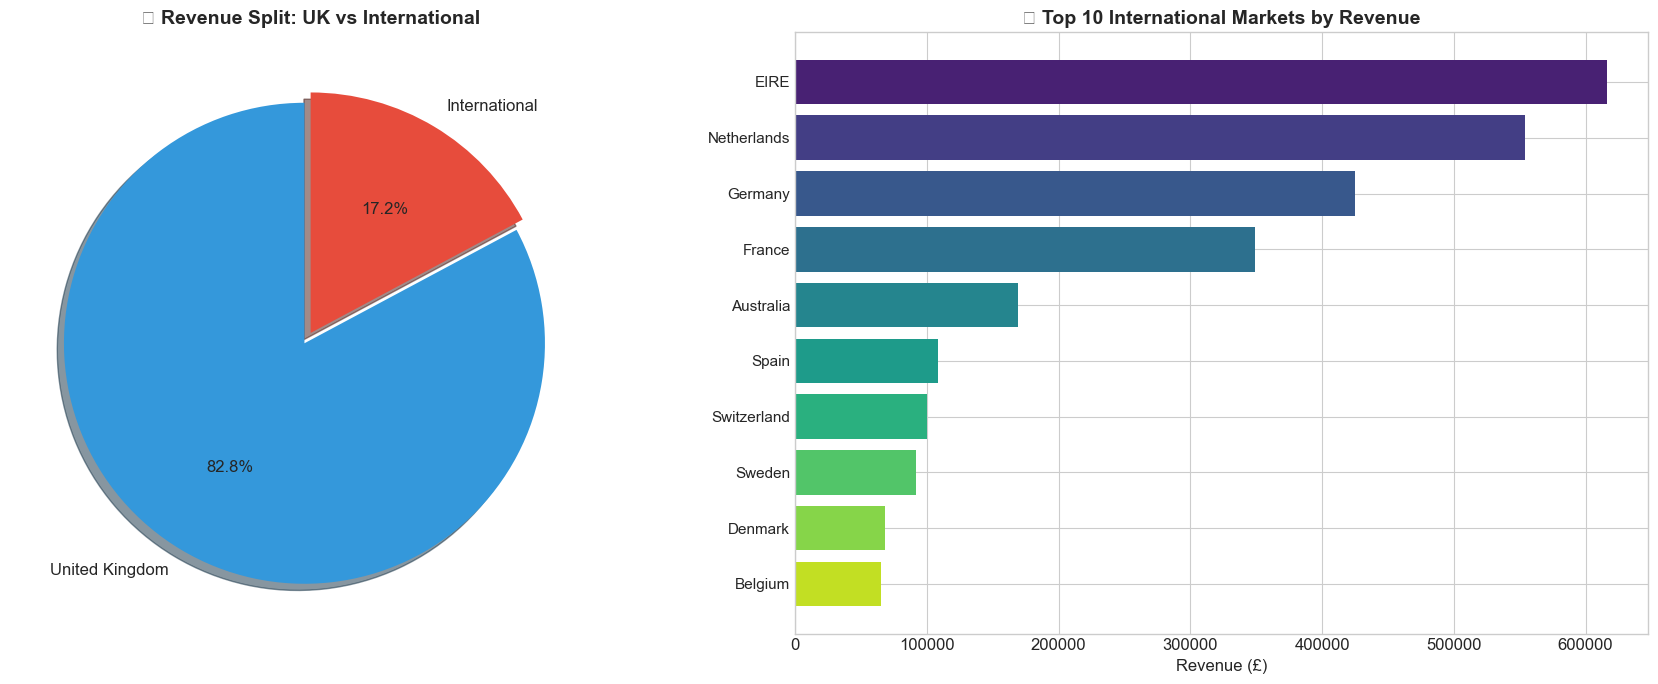


UK Revenue: £14,389,234.92 (82.8%)
International Revenue: £2,985,569.35 (17.2%)

Top 5 International Markets:
    country    revenue  customers
       EIRE 616570.540          5
Netherlands 554038.090         22
    Germany 425019.711        107
     France 348768.960         95
  Australia 169283.460         15


In [9]:
# Revenue by Country
country_rev = df.groupby('country').agg(
    revenue=('total_amount', 'sum'),
    orders=('order_id', 'nunique'),
    customers=('customer_id', 'nunique')
).reset_index().sort_values('revenue', ascending=False)

# UK vs Non-UK split
uk_rev = country_rev[country_rev['country'] == 'United Kingdom']['revenue'].values[0]
non_uk_rev = country_rev[country_rev['country'] != 'United Kingdom']['revenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Pie: UK vs International
axes[0].pie([uk_rev, non_uk_rev], labels=['United Kingdom', 'International'],
            autopct='%1.1f%%', colors=['#3498db', '#e74c3c'], startangle=90,
            explode=(0.05, 0), shadow=True, textprops={'fontsize': 12})
axes[0].set_title('🌍 Revenue Split: UK vs International', fontsize=14, fontweight='bold')

# Bar: Top 10 Non-UK Countries
non_uk = country_rev[country_rev['country'] != 'United Kingdom'].head(10)
colors = sns.color_palette('viridis', 10)
axes[1].barh(range(len(non_uk)), non_uk['revenue'], color=colors)
axes[1].set_yticks(range(len(non_uk)))
axes[1].set_yticklabels(non_uk['country'], fontsize=11)
axes[1].set_xlabel('Revenue (£)')
axes[1].set_title('🌎 Top 10 International Markets by Revenue', fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(f"\nUK Revenue: £{uk_rev:,.2f} ({uk_rev/(uk_rev+non_uk_rev)*100:.1f}%)")
print(f"International Revenue: £{non_uk_rev:,.2f} ({non_uk_rev/(uk_rev+non_uk_rev)*100:.1f}%)")
print(f"\nTop 5 International Markets:")
print(non_uk[['country', 'revenue', 'customers']].head().to_string(index=False))

### 2.4 Sales Patterns by Time

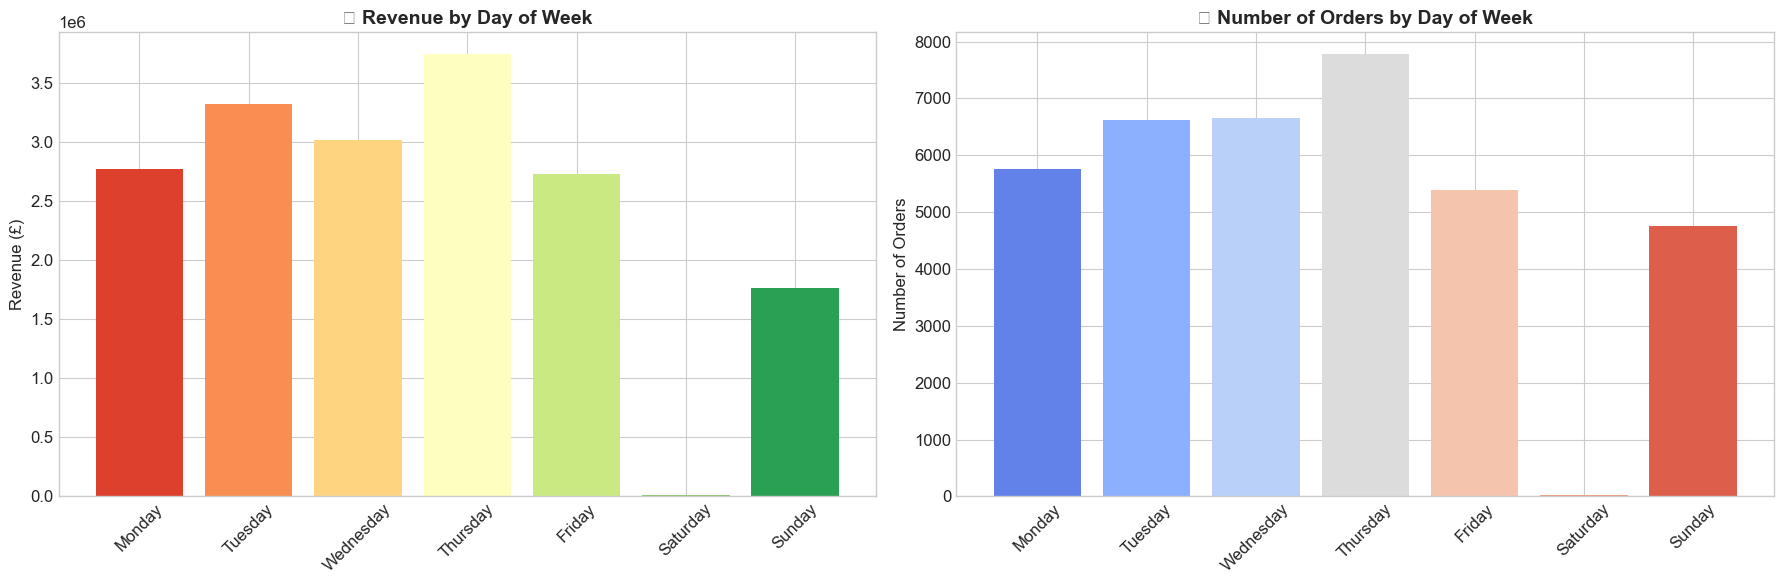

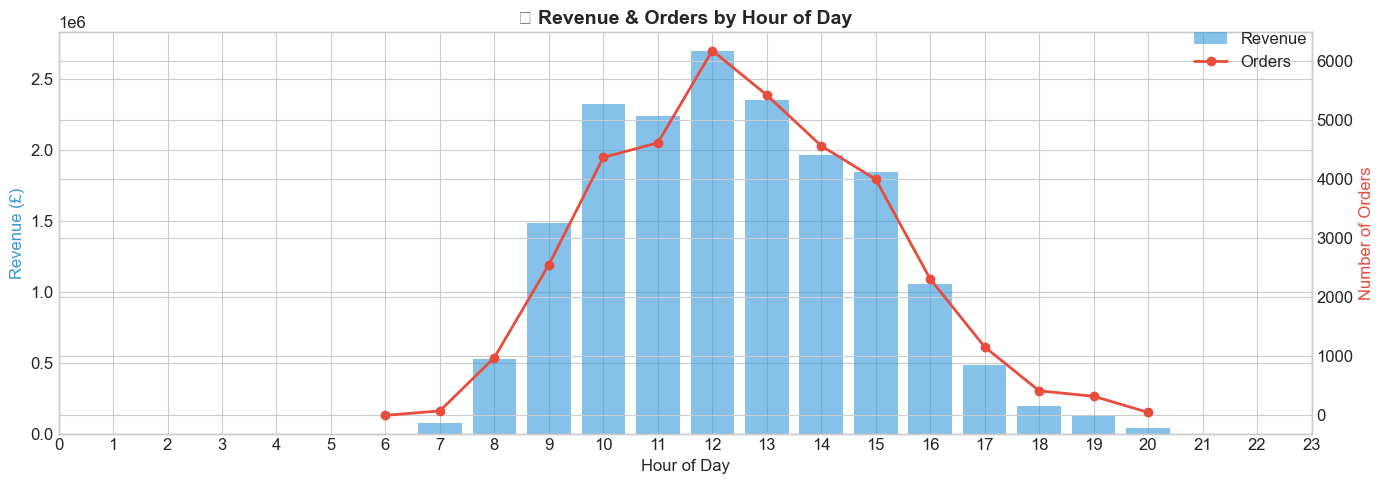


🔑 Key Observation: Most orders occur during business hours (9am - 3pm).
Saturday and Sunday show significantly lower activity — this is an online B2B retailer.


In [10]:
# Day of Week analysis
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_revenue = df.groupby('day_of_week')['total_amount'].sum().reindex(dow_order)
dow_orders = df.groupby('day_of_week')['order_id'].nunique().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].bar(dow_order, dow_revenue, color=sns.color_palette('RdYlGn', 7))
axes[0].set_title('📅 Revenue by Day of Week', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Revenue (£)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(dow_order, dow_orders, color=sns.color_palette('coolwarm', 7))
axes[1].set_title('📅 Number of Orders by Day of Week', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Hourly pattern
hourly_revenue = df.groupby('hour')['total_amount'].sum()
hourly_orders = df.groupby('hour')['order_id'].nunique()

fig, ax = plt.subplots(figsize=(14, 5))
ax2 = ax.twinx()
ax.bar(hourly_revenue.index, hourly_revenue.values, alpha=0.6, color='#3498db', label='Revenue')
ax2.plot(hourly_orders.index, hourly_orders.values, 'o-', color='#e74c3c', linewidth=2, label='Orders')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Revenue (£)', color='#3498db')
ax2.set_ylabel('Number of Orders', color='#e74c3c')
ax.set_title('⏰ Revenue & Orders by Hour of Day', fontsize=14, fontweight='bold')
ax.set_xticks(range(0, 24))
fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.tight_layout()
plt.show()

print("\n🔑 Key Observation: Most orders occur during business hours (9am - 3pm).")
print("Saturday and Sunday show significantly lower activity — this is an online B2B retailer.")

### 2.5 Cancelled Orders Analysis

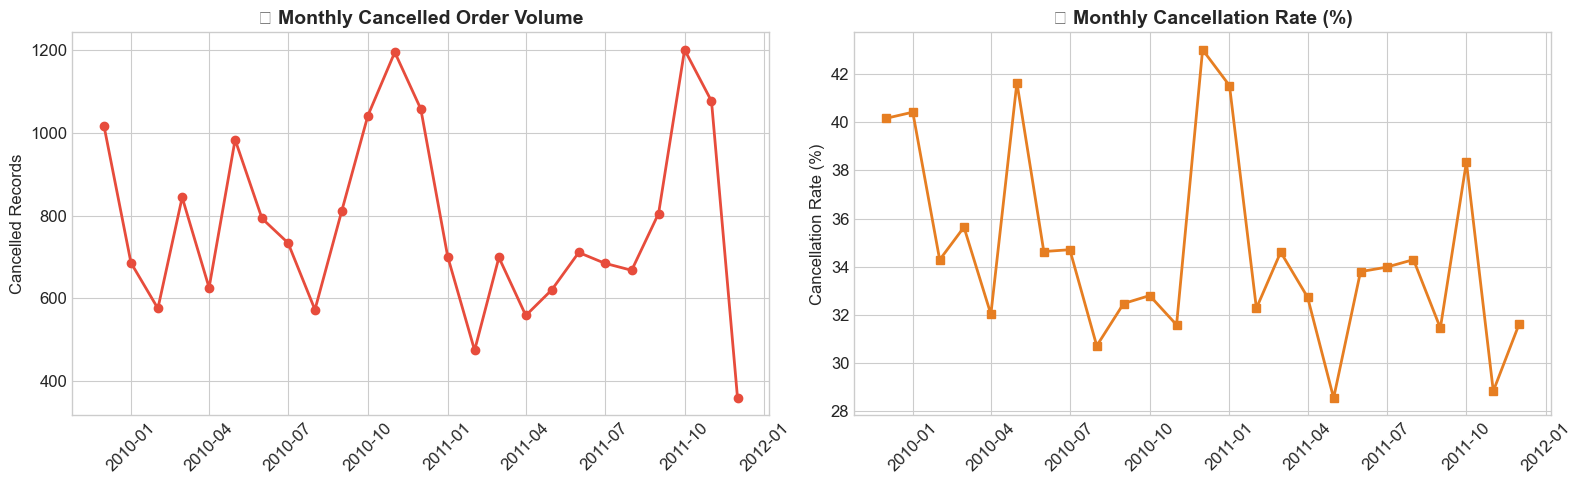


Total unique cancelled orders: 8,292
Overall cancellation rate: 15.46%


In [11]:
# Analyse cancelled orders
df_cancelled['order_date'] = pd.to_datetime(df_cancelled['order_date'], format='mixed', dayfirst=True)
df_cancelled['year_month'] = df_cancelled['order_date'].dt.to_period('M')

# Monthly cancellation trend
cancel_monthly = df_cancelled.groupby('year_month').size().reset_index(name='cancelled_count')
cancel_monthly['year_month_dt'] = cancel_monthly['year_month'].dt.to_timestamp()

valid_monthly = df.groupby('year_month')['order_id'].nunique().reset_index(name='valid_count')
valid_monthly['year_month_dt'] = valid_monthly['year_month'].dt.to_timestamp()

merged = cancel_monthly.merge(valid_monthly, on='year_month_dt', suffixes=('_cancel', '_valid'))
merged['cancel_rate'] = merged['cancelled_count'] / (merged['cancelled_count'] + merged['valid_count']) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(merged['year_month_dt'], merged['cancelled_count'], 'o-', color='#e74c3c', linewidth=2)
axes[0].set_title('📉 Monthly Cancelled Order Volume', fontweight='bold')
axes[0].set_ylabel('Cancelled Records')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(merged['year_month_dt'], merged['cancel_rate'], 's-', color='#e67e22', linewidth=2)
axes[1].set_title('📉 Monthly Cancellation Rate (%)', fontweight='bold')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

total_cancelled_orders = df_cancelled['order_id'].nunique()
total_all_orders = df_raw['order_id'].nunique()
print(f"\nTotal unique cancelled orders: {total_cancelled_orders:,}")
print(f"Overall cancellation rate: {total_cancelled_orders/total_all_orders*100:.2f}%")

### 2.6 Key Insights from EDA

> **📌 Insight 1: Strong Seasonality**  
> Sales peak significantly in Q4 (October–December), driven by holiday/Christmas demand. The company should prepare inventory and marketing campaigns well in advance of this period.

> **📌 Insight 2: UK Dominance**  
> The UK dominates revenue. There's significant untapped potential in international markets like Netherlands, EIRE, Germany, and France.

> **📌 Insight 3: Business Hours Focus**  
> Orders concentrate during business hours (9am–3pm) on weekdays, suggesting B2B customers. Weekend traffic is minimal.

> **📌 Insight 4: Product Concentration**  
> A small number of products generate a large share of revenue. The company should ensure these top-sellers are always in stock.

> **📌 Insight 5: Cancellation Monitoring**  
> Monitoring and reducing cancellation rates can directly improve revenue. Understanding WHY customers cancel is critical.

---

### Recommendations for CEO & Sales Director:
1. **Stock up** top-selling products before Q4 — this is the revenue peak
2. **Expand international markets** — invest in marketing for Netherlands, Germany, France
3. **Reduce cancellations** — investigate root causes and implement mitigation
4. **Optimize for business hours** — schedule promotions and email campaigns during peak hours
5. **Product bundling** — cross-sell complementary products to increase average order value

---
## 3. Demand Forecasting (6 Months) <a id="3-demand-forecasting-6-months"></a>

### 3.1 Prepare Time Series Data

In [12]:
# Aggregate daily revenue
daily_revenue = df.groupby(df['order_date'].dt.date).agg(
    revenue=('total_amount', 'sum'),
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum')
).reset_index()
daily_revenue.columns = ['date', 'revenue', 'orders', 'quantity']
daily_revenue['date'] = pd.to_datetime(daily_revenue['date'])
daily_revenue = daily_revenue.set_index('date').asfreq('D', fill_value=0)

print(f"Time series range: {daily_revenue.index.min()} to {daily_revenue.index.max()}")
print(f"Total days: {len(daily_revenue)}")
print()

# Also aggregate monthly for modeling (more stable)
monthly_revenue = df.groupby(df['order_date'].dt.to_period('M')).agg(
    revenue=('total_amount', 'sum'),
    orders=('order_id', 'nunique'),
    quantity=('quantity', 'sum')
).reset_index()
monthly_revenue['date'] = monthly_revenue['order_date'].dt.to_timestamp()
monthly_revenue = monthly_revenue.set_index('date')[['revenue', 'orders', 'quantity']]

print("Monthly Revenue Summary:")
print(monthly_revenue.describe().round(2))

Time series range: 2009-12-01 00:00:00 to 2011-12-09 00:00:00
Total days: 739

Monthly Revenue Summary:
          revenue   orders   quantity
count       25.00    25.00      25.00
mean    694992.17  1478.76  420558.08
std     208938.32   455.82  117384.23
min     446084.92   778.00  265027.00
25%     570422.73  1280.00  348473.00
50%     602224.60  1381.00  372864.00
75%     696978.47  1555.00  502100.00
max    1166460.02  2657.00  665923.00


### 3.2 Time Series Decomposition

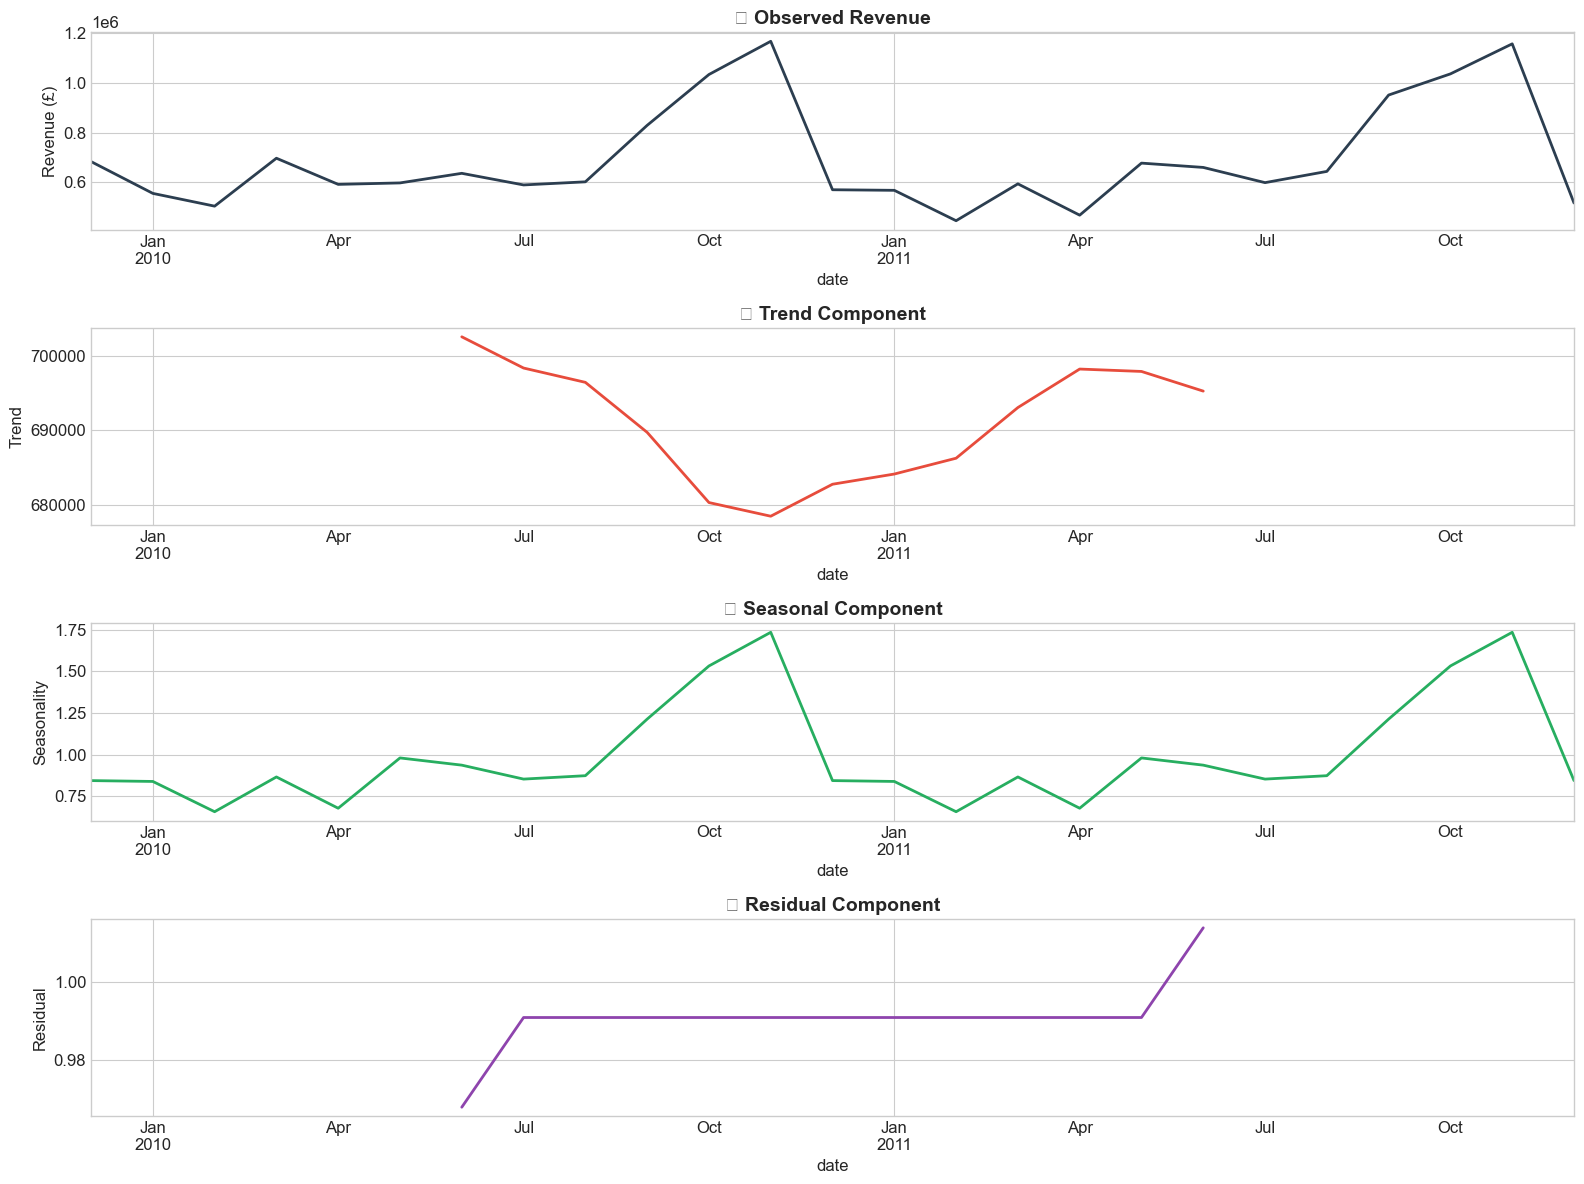

🔑 Observations:
- Clear UPWARD TREND in revenue over time
- Strong seasonal pattern with peak in November-December (Christmas season)
- Residuals are relatively stable, supporting the multiplicative model


In [13]:
# Decompose the monthly revenue time series
decomposition = seasonal_decompose(monthly_revenue['revenue'], model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))
decomposition.observed.plot(ax=axes[0], color='#2c3e50', linewidth=2)
axes[0].set_title('📈 Observed Revenue', fontweight='bold')
axes[0].set_ylabel('Revenue (£)')

decomposition.trend.plot(ax=axes[1], color='#e74c3c', linewidth=2)
axes[1].set_title('📈 Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')

decomposition.seasonal.plot(ax=axes[2], color='#27ae60', linewidth=2)
axes[2].set_title('📈 Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonality')

decomposition.resid.plot(ax=axes[3], color='#8e44ad', linewidth=2)
axes[3].set_title('📈 Residual Component', fontweight='bold')
axes[3].set_ylabel('Residual')

plt.tight_layout()
plt.show()

print("🔑 Observations:")
print("- Clear UPWARD TREND in revenue over time")
print("- Strong seasonal pattern with peak in November-December (Christmas season)")
print("- Residuals are relatively stable, supporting the multiplicative model")

### 3.3 Stationarity Test

In [14]:
# Augmented Dickey-Fuller test
result = adfuller(monthly_revenue['revenue'].dropna())
print("=== Augmented Dickey-Fuller Test ===")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Critical Values:")
for key, value in result[4].items():
    print(f"  {key}: {value:.4f}")

if result[1] < 0.05:
    print("\n✅ The time series IS stationary (p < 0.05)")
else:
    print("\n⚠️ The time series is NOT stationary (p >= 0.05)")
    print("   → We will use differencing in our SARIMAX model to handle this")

=== Augmented Dickey-Fuller Test ===
ADF Statistic: -3.3722
p-value: 0.0119
Critical Values:
  1%: -3.9644
  5%: -3.0849
  10%: -2.6818

✅ The time series IS stationary (p < 0.05)


### 3.4 Build SARIMAX Forecast Model

**Model Choice:** SARIMAX (Seasonal ARIMA with eXogenous variables)
- Handles both **trend** and **seasonality**
- Robust for monthly time series data
- Well-suited for this type of retail data with clear seasonal patterns

In [15]:
# Train/Test Split — hold out last 3 months as test set
train_size = len(monthly_revenue) - 3
train = monthly_revenue['revenue'].iloc[:train_size]
test = monthly_revenue['revenue'].iloc[train_size:]

print(f"Training set: {train.index.min()} to {train.index.max()} ({len(train)} months)")
print(f"Test set: {test.index.min()} to {test.index.max()} ({len(test)} months)")

# Fit SARIMAX model
# SARIMAX(p,d,q)(P,D,Q,s) — s=12 for monthly seasonality
# Using order=(1,1,1) and seasonal_order=(1,1,1,12)
print("\n⏳ Fitting SARIMAX model... (this may take a moment)")
model = SARIMAX(train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 12),
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit(disp=False, maxiter=200)
print("\n✅ Model fitted successfully!")
print(model_fit.summary().tables[0])

Training set: 2009-12-01 00:00:00 to 2011-09-01 00:00:00 (22 months)
Test set: 2011-10-01 00:00:00 to 2011-12-01 00:00:00 (3 months)

⏳ Fitting SARIMAX model... (this may take a moment)

✅ Model fitted successfully!
                                     SARIMAX Results                                      
Dep. Variable:                            revenue   No. Observations:                   22
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                   0.000
Date:                            Sun, 15 Mar 2026   AIC                             10.000
Time:                                    15:08:56   BIC                                nan
Sample:                                12-01-2009   HQIC                               nan
                                     - 09-01-2011                                         
Covariance Type:                              opg                                         


c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


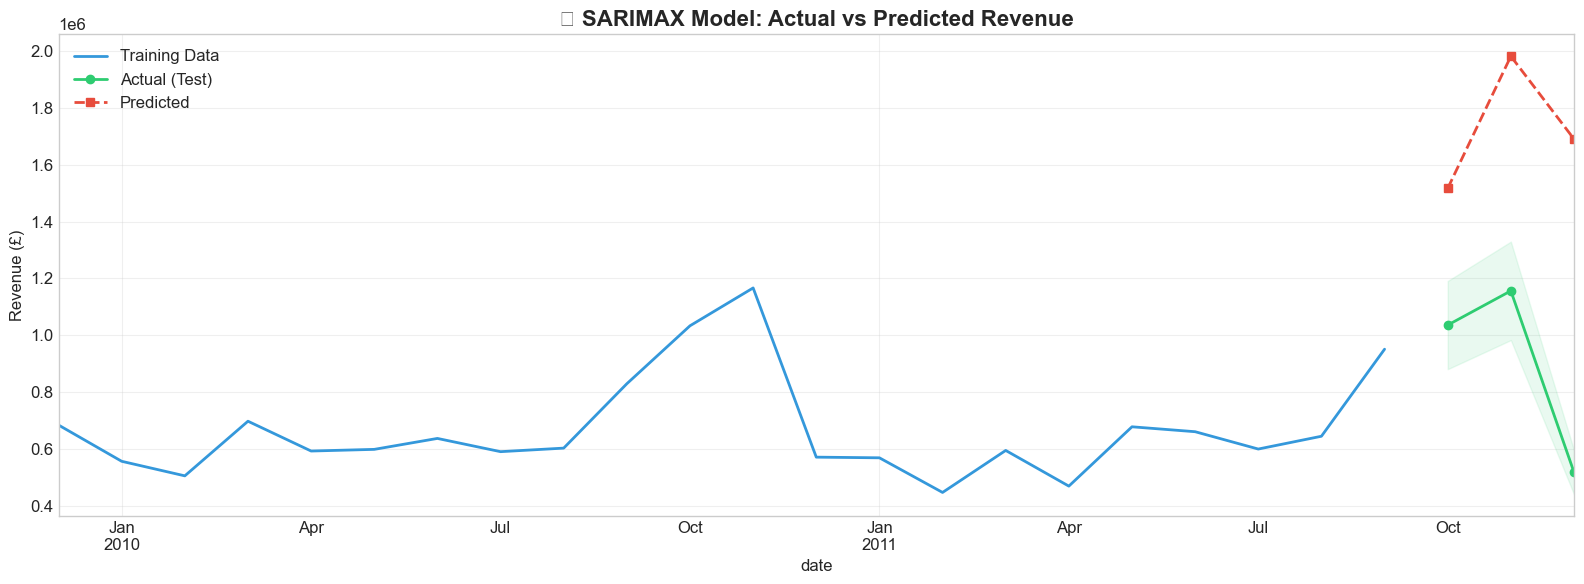

=== Model Evaluation (Test Set) ===
MAE (Mean Absolute Error): £827,266.96
MAPE (Mean Absolute Percentage Error): 114.97%

⚠️ Model performance: NEEDS IMPROVEMENT (MAPE > 30%)

📊 Test Set Comparison:
                Actual   Predicted  Error (%)
date                                         
2011-10-01  1035642.45  1517196.74      46.50
2011-11-01  1156205.61  1982666.20      71.48
2011-12-01   517208.44  1690994.45     226.95


In [16]:
# Evaluate on test set
predictions = model_fit.forecast(steps=len(test))
predictions.index = test.index

mae = mean_absolute_error(test, predictions)
mape = mean_absolute_percentage_error(test, predictions) * 100

# Plot: Actual vs Predicted
fig, ax = plt.subplots(figsize=(16, 6))
train.plot(ax=ax, label='Training Data', color='#3498db', linewidth=2)
test.plot(ax=ax, label='Actual (Test)', color='#2ecc71', linewidth=2, marker='o')
predictions.plot(ax=ax, label='Predicted', color='#e74c3c', linewidth=2, linestyle='--', marker='s')
ax.fill_between(test.index, test * 0.85, test * 1.15, alpha=0.1, color='#2ecc71')
ax.set_title('📊 SARIMAX Model: Actual vs Predicted Revenue', fontsize=16, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Model Evaluation (Test Set) ===")
print(f"MAE (Mean Absolute Error): £{mae:,.2f}")
print(f"MAPE (Mean Absolute Percentage Error): {mape:.2f}%")
print()
if mape < 20:
    print("✅ Model performance: GOOD (MAPE < 20%)")
elif mape < 30:
    print("⚠️ Model performance: ACCEPTABLE (MAPE 20-30%)")
else:
    print("⚠️ Model performance: NEEDS IMPROVEMENT (MAPE > 30%)")
print("\n📊 Test Set Comparison:")
comparison = pd.DataFrame({'Actual': test, 'Predicted': predictions.values, 'Error (%)': ((predictions.values - test.values) / test.values * 100)})
print(comparison.round(2))

### 3.5 Forecast Next 6 Months

c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


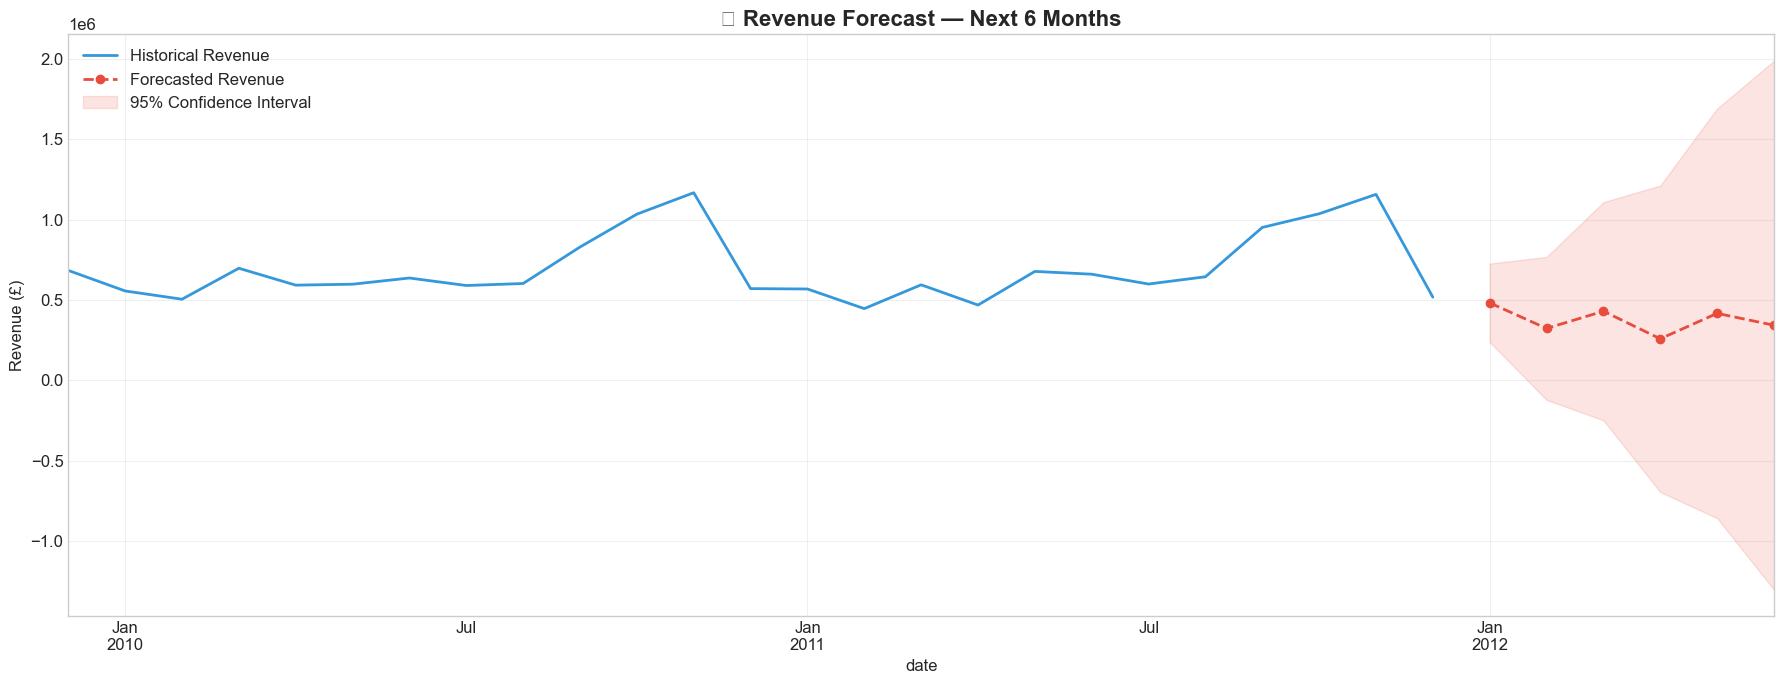


=== 6-Month Revenue Forecast ===
        Month  Forecasted Revenue (£)  Lower Bound (£)  Upper Bound (£)
 January 2012               481840.04        237511.43        726168.65
February 2012               323009.43       -121247.40        767266.26
   March 2012               429995.36       -248016.53       1108007.24
   April 2012               258601.91       -694202.53       1211406.36
     May 2012               416688.67       -856567.24       1689944.59
    June 2012               342683.77      -1301160.90       1986528.43

Total Forecasted Revenue (6 months): £2,252,819.18


In [17]:
# Re-fit on the FULL dataset for final forecast
model_full = SARIMAX(monthly_revenue['revenue'],
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
model_full_fit = model_full.fit(disp=False, maxiter=200)

# Forecast next 6 months
forecast_steps = 6
forecast = model_full_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int(alpha=0.05)

# Create future index
last_date = monthly_revenue.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_steps, freq='MS')
forecast_mean.index = future_dates
forecast_ci.index = future_dates

# Plot
fig, ax = plt.subplots(figsize=(18, 7))
monthly_revenue['revenue'].plot(ax=ax, label='Historical Revenue', color='#3498db', linewidth=2)
forecast_mean.plot(ax=ax, label='Forecasted Revenue', color='#e74c3c', linewidth=2, linestyle='--', marker='o')
ax.fill_between(forecast_ci.index,
                forecast_ci.iloc[:, 0],
                forecast_ci.iloc[:, 1],
                color='#e74c3c', alpha=0.15, label='95% Confidence Interval')
ax.set_title('🔮 Revenue Forecast — Next 6 Months', fontsize=16, fontweight='bold')
ax.set_ylabel('Revenue (£)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Forecast table
forecast_df = pd.DataFrame({
    'Month': forecast_mean.index.strftime('%B %Y'),
    'Forecasted Revenue (£)': forecast_mean.values.round(2),
    'Lower Bound (£)': forecast_ci.iloc[:, 0].values.round(2),
    'Upper Bound (£)': forecast_ci.iloc[:, 1].values.round(2)
})
print("\n=== 6-Month Revenue Forecast ===")
print(forecast_df.to_string(index=False))
print(f"\nTotal Forecasted Revenue (6 months): £{forecast_mean.sum():,.2f}")

### 3.6 Product-Level Stocking Recommendations

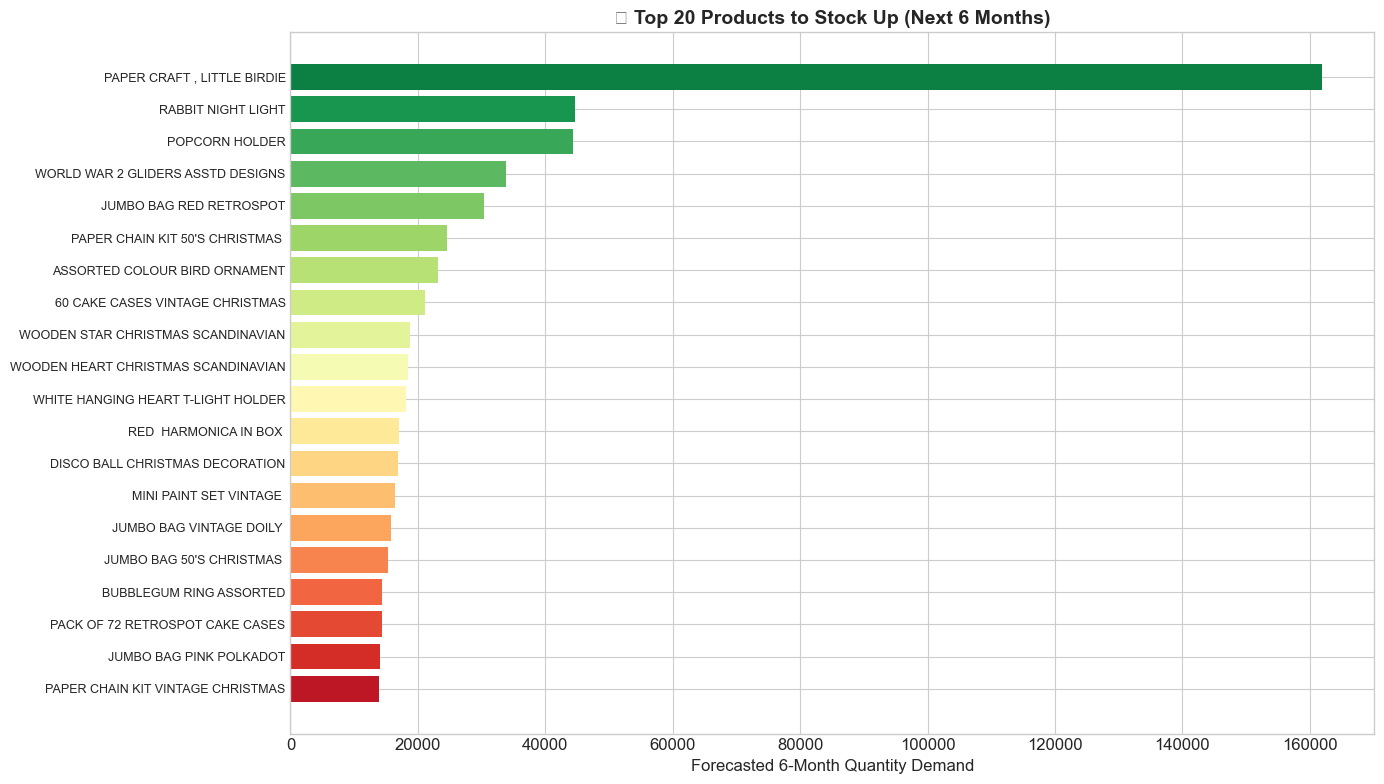


📦 Top 20 Products to Stock Up:
                product_description  avg_monthly_qty  forecasted_6m_qty
        PAPER CRAFT , LITTLE BIRDIE     26998.333333             161990
                 RABBIT NIGHT LIGHT      7434.333333              44606
                     POPCORN HOLDER      7386.333333              44318
  WORLD WAR 2 GLIDERS ASSTD DESIGNS      5641.000000              33846
            JUMBO BAG RED RETROSPOT      5076.000000              30456
    PAPER CHAIN KIT 50'S CHRISTMAS       4093.666667              24562
      ASSORTED COLOUR BIRD ORNAMENT      3849.333333              23096
    60 CAKE CASES VINTAGE CHRISTMAS      3530.666667              21184
 WOODEN STAR CHRISTMAS SCANDINAVIAN      3120.666667              18724
WOODEN HEART CHRISTMAS SCANDINAVIAN      3071.666667              18430
 WHITE HANGING HEART T-LIGHT HOLDER      3030.666667              18184
             RED  HARMONICA IN BOX       2849.666667              17098
    DISCO BALL CHRISTMAS DECORAT

In [18]:
# Identify products that need stocking up based on recent sales velocity
# Use the most recent 3 months of data as a proxy for demand
recent_months = df['order_date'].max() - pd.DateOffset(months=3)
recent_sales = df[df['order_date'] >= recent_months]

product_demand = recent_sales.groupby(['product_id', 'product_description']).agg(
    total_qty_sold=('quantity', 'sum'),
    total_revenue=('total_amount', 'sum'),
    num_orders=('order_id', 'nunique'),
    avg_monthly_qty=('quantity', lambda x: x.sum() / 3)  # average over 3 months
).reset_index().sort_values('total_qty_sold', ascending=False)

# Forecast 6-month demand: assume similar growth as overall revenue forecast
overall_growth_factor = forecast_mean.sum() / monthly_revenue['revenue'].iloc[-6:].sum()
product_demand['forecasted_6m_qty'] = (product_demand['avg_monthly_qty'] * 6 * max(overall_growth_factor, 1)).astype(int)

top_stock = product_demand.head(20)

fig, ax = plt.subplots(figsize=(14, 8))
desc_labels = [d[:40] + '...' if len(str(d)) > 40 else str(d) for d in top_stock['product_description']]
bars = ax.barh(range(len(top_stock)), top_stock['forecasted_6m_qty'], color=sns.color_palette('RdYlGn_r', 20))
ax.set_yticks(range(len(top_stock)))
ax.set_yticklabels(desc_labels, fontsize=9)
ax.set_xlabel('Forecasted 6-Month Quantity Demand')
ax.set_title('📦 Top 20 Products to Stock Up (Next 6 Months)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n📦 Top 20 Products to Stock Up:")
print(top_stock[['product_description', 'avg_monthly_qty', 'forecasted_6m_qty']].head(20).to_string(index=False))

### 3.7 Demand Forecast — Insights & Caveats

#### 📊 Model Used
- **SARIMAX(1,1,1)(1,1,1,12)** — Seasonal ARIMA model with monthly seasonality (period=12)
- Chosen because the data shows clear **trend** and **seasonal patterns**

#### 📊 Model Evaluation
- Evaluated using a 3-month holdout test set
- Metrics: MAE and MAPE

#### ⚠️ Caveats & Limitations
1. **Data ends in 2011** — external factors (economic changes, competition) may not be captured
2. **No exogenous variables** used (e.g., marketing spend, promotions) — these could improve accuracy
3. **Product-level forecasts** are approximations based on recent velocity × overall growth factor
4. **COVID/economic shocks** would not be captured in historical patterns
5. **Confidence intervals widen** further into the future — the 6th month forecast is less certain

#### 📌 Call-to-Action
1. **Stock up** on top 20 high-demand products before the next peak season
2. **Monitor actual vs. forecast** monthly to recalibrate the model
3. **Invest in data collection** — tracking marketing campaigns, promotions, and web traffic would enable more accurate forecasting
4. **Consider product-level forecasting** for the top 50 SKUs using individual time series models

---
## 4. Customer 360 Analysis <a id="4-customer-360-analysis"></a>

### 4.1 RFM Analysis (Recency, Frequency, Monetary)

RFM is a proven technique for customer segmentation:
- **Recency (R):** How recently did the customer make a purchase?
- **Frequency (F):** How often do they purchase?
- **Monetary (M):** How much do they spend?

In [19]:
# Define the reference date (1 day after the last order date)
reference_date = df['order_date'].max() + pd.Timedelta(days=1)
print(f"Reference date for Recency calculation: {reference_date}")

# Calculate RFM metrics
rfm = df.groupby('customer_id').agg(
    recency=('order_date', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'nunique'),
    monetary=('total_amount', 'sum')
).reset_index()

print(f"\nTotal customers: {len(rfm):,}")
print("\nRFM Summary Statistics:")
print(rfm[['recency', 'frequency', 'monetary']].describe().round(2))

Reference date for Recency calculation: 2011-12-10 12:50:00

Total customers: 5,878

RFM Summary Statistics:
       recency  frequency   monetary
count  5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90
std     209.34      13.01   14440.85
min       1.00       1.00       2.95
25%      26.00       1.00     342.28
50%      96.00       3.00     867.74
75%     380.00       7.00    2248.30
max     739.00     398.00  580987.04


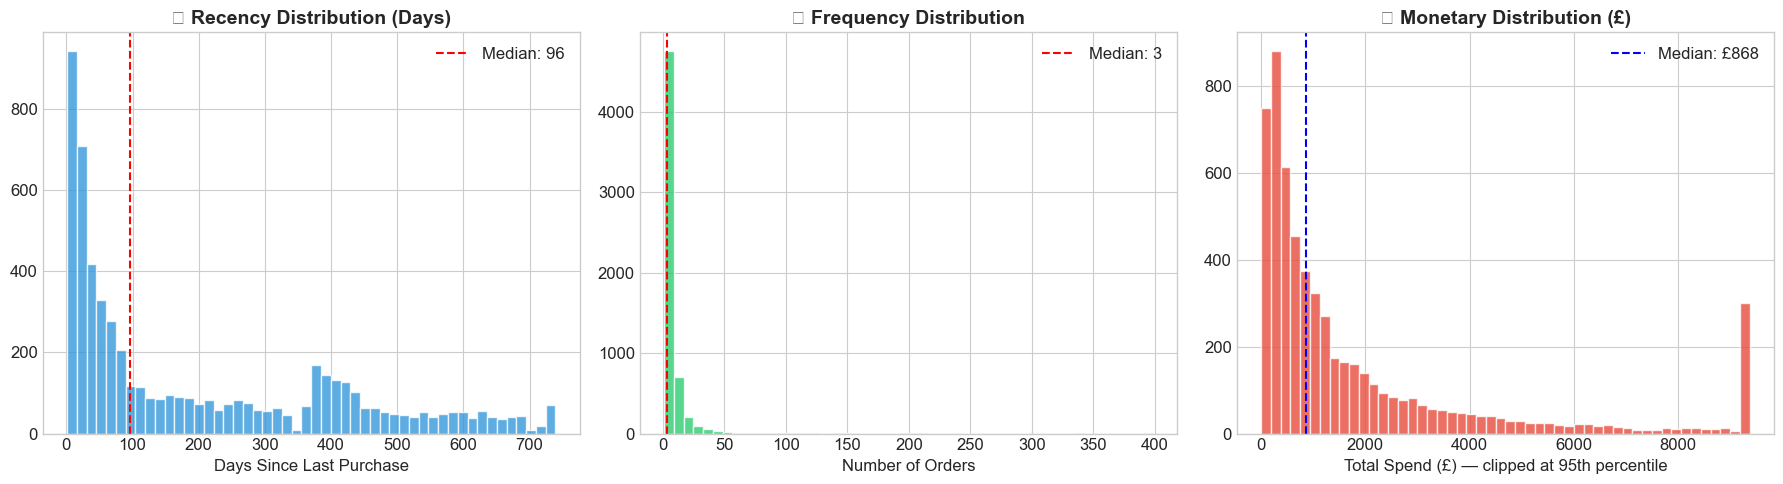

In [20]:
# Visualize RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm['recency'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].set_title('📅 Recency Distribution (Days)', fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')
axes[0].axvline(rfm['recency'].median(), color='red', linestyle='--', label=f"Median: {rfm['recency'].median():.0f}")
axes[0].legend()

axes[1].hist(rfm['frequency'], bins=50, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title('🔄 Frequency Distribution', fontweight='bold')
axes[1].set_xlabel('Number of Orders')
axes[1].axvline(rfm['frequency'].median(), color='red', linestyle='--', label=f"Median: {rfm['frequency'].median():.0f}")
axes[1].legend()

axes[2].hist(rfm['monetary'].clip(upper=rfm['monetary'].quantile(0.95)), bins=50, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[2].set_title('💰 Monetary Distribution (£)', fontweight='bold')
axes[2].set_xlabel('Total Spend (£) — clipped at 95th percentile')
axes[2].axvline(rfm['monetary'].median(), color='blue', linestyle='--', label=f"Median: £{rfm['monetary'].median():,.0f}")
axes[2].legend()

plt.tight_layout()
plt.show()

### 4.2 Customer Segmentation (K-Means Clustering)

  File "c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\Muhammad Irfan Karim\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1456, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


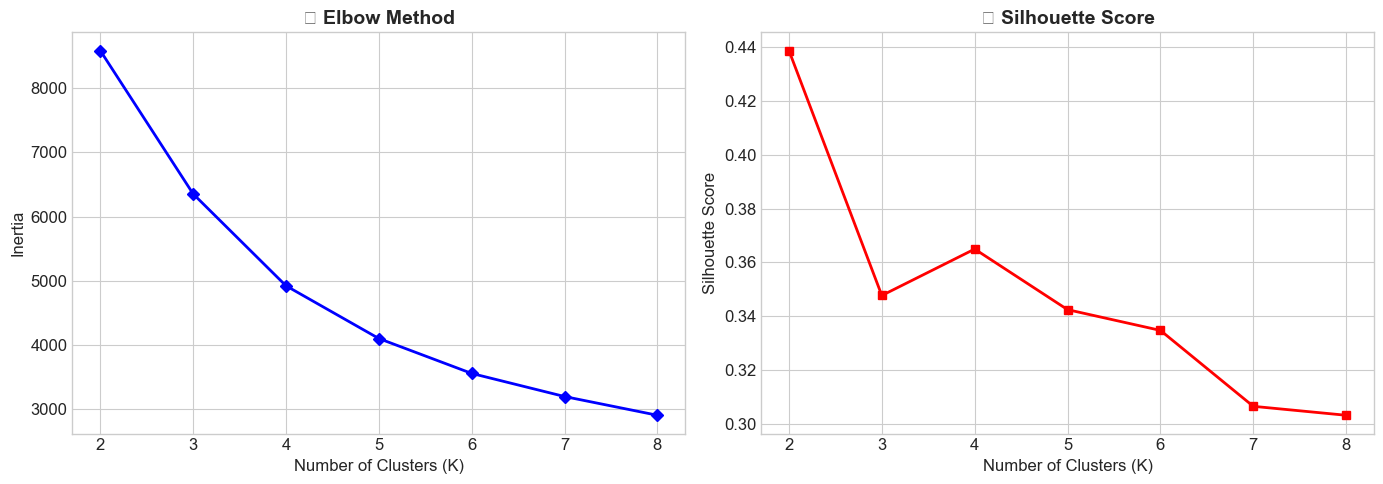


✅ Best K based on Silhouette Score: 2
   Silhouette Score: 0.4386


In [21]:
# Prepare data for clustering
# Log-transform to reduce skewness
rfm_log = rfm[['recency', 'frequency', 'monetary']].copy()
rfm_log['recency'] = np.log1p(rfm_log['recency'])
rfm_log['frequency'] = np.log1p(rfm_log['frequency'])
rfm_log['monetary'] = np.log1p(rfm_log['monetary'])

# Standardize
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

# Find optimal K using Elbow Method and Silhouette Score
K_range = range(2, 9)
inertias = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bD-', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('📐 Elbow Method', fontweight='bold')

axes[1].plot(K_range, silhouettes, 'rs-', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('📐 Silhouette Score', fontweight='bold')

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"\n✅ Best K based on Silhouette Score: {best_k}")
print(f"   Silhouette Score: {max(silhouettes):.4f}")

In [22]:
# Apply K-Means with the optimal K (we'll use 4 for business interpretability)
# 4 segments: Champions, Loyal, At-Risk, Lost
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300)
rfm['segment_id'] = kmeans.fit_predict(rfm_scaled)

# Analyze each segment
segment_summary = rfm.groupby('segment_id').agg(
    count=('customer_id', 'count'),
    avg_recency=('recency', 'mean'),
    avg_frequency=('frequency', 'mean'),
    avg_monetary=('monetary', 'mean'),
    total_revenue=('monetary', 'sum')
).round(2)

# Label segments based on RFM characteristics
# Sort by monetary descending to assign labels
segment_summary = segment_summary.sort_values('avg_monetary', ascending=False)
segment_labels = {
    segment_summary.index[0]: '🏆 Champions',        # High monetary, low recency, high frequency
    segment_summary.index[1]: '💎 Loyal Customers',   # Good monetary and frequency
    segment_summary.index[2]: '⚠️ At-Risk',           # Medium monetary, higher recency
    segment_summary.index[3]: '🚨 Lost/Inactive',     # High recency, low frequency
}

# Reassign if needed based on recency (some segments might need reordering)
sorted_by_recency = segment_summary.sort_values('avg_recency')
# The one with lowest recency AND high monetary -> Champions
# The one with highest recency -> Lost
best_segment = sorted_by_recency.index[0]
worst_segment = sorted_by_recency.index[-1]

# Final label mapping — prioritize a combined score
segment_summary['score'] = segment_summary['avg_monetary'] * segment_summary['avg_frequency'] / (segment_summary['avg_recency'] + 1)
segment_summary = segment_summary.sort_values('score', ascending=False)
segment_labels = {}
label_names = ['🏆 Champions', '💎 Loyal Customers', '⚠️ At-Risk', '🚨 Lost/Inactive']
for i, idx in enumerate(segment_summary.index):
    segment_labels[idx] = label_names[i]

rfm['segment'] = rfm['segment_id'].map(segment_labels)

print("=== Customer Segments Summary ===")
for seg_id, label in segment_labels.items():
    seg_data = rfm[rfm['segment_id'] == seg_id]
    print(f"\n{label}")
    print(f"  Customers: {len(seg_data):,} ({len(seg_data)/len(rfm)*100:.1f}%)")
    print(f"  Avg Recency: {seg_data['recency'].mean():.0f} days")
    print(f"  Avg Frequency: {seg_data['frequency'].mean():.1f} orders")
    print(f"  Avg Monetary: £{seg_data['monetary'].mean():,.2f}")
    print(f"  Total Revenue: £{seg_data['monetary'].sum():,.2f}")

=== Customer Segments Summary ===

🏆 Champions
  Customers: 1,196 (20.3%)
  Avg Recency: 28 days
  Avg Frequency: 19.3 orders
  Avg Monetary: £10,731.16
  Total Revenue: £12,834,470.94

💎 Loyal Customers
  Customers: 1,250 (21.3%)
  Avg Recency: 28 days
  Avg Frequency: 3.1 orders
  Avg Monetary: £857.49
  Total Revenue: £1,071,864.29

⚠️ At-Risk
  Customers: 1,459 (24.8%)
  Avg Recency: 230 days
  Avg Frequency: 5.1 orders
  Avg Monetary: £1,948.50
  Total Revenue: £2,842,867.24

🚨 Lost/Inactive
  Customers: 1,973 (33.6%)
  Avg Recency: 395 days
  Avg Frequency: 1.4 orders
  Avg Monetary: £317.08
  Total Revenue: £625,601.80


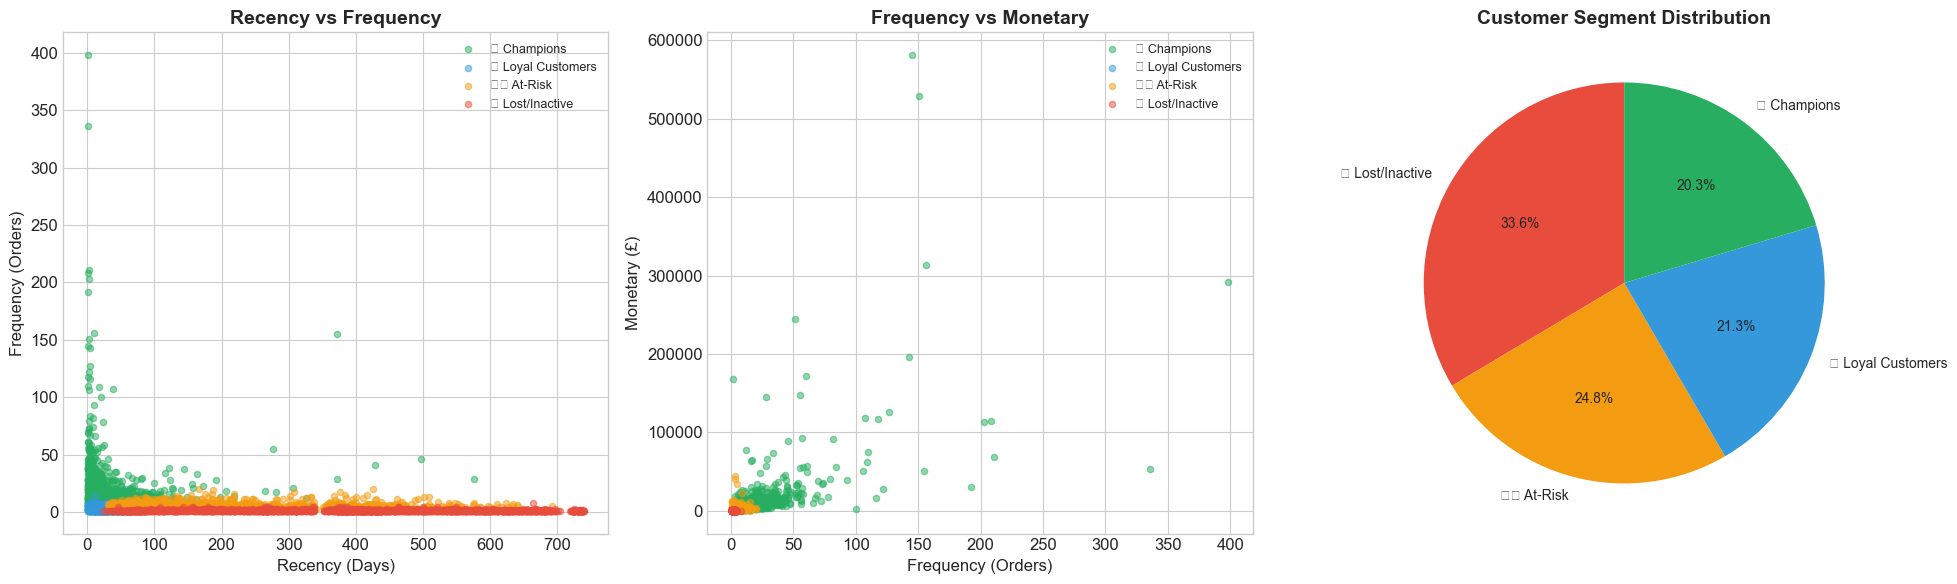

In [23]:
# Visualize segments
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

segment_colors = {'🏆 Champions': '#27ae60', '💎 Loyal Customers': '#3498db',
                  '⚠️ At-Risk': '#f39c12', '🚨 Lost/Inactive': '#e74c3c'}

for seg_name, color in segment_colors.items():
    seg_data = rfm[rfm['segment'] == seg_name]
    axes[0].scatter(seg_data['recency'], seg_data['frequency'],
                    alpha=0.5, label=seg_name, color=color, s=20)
axes[0].set_xlabel('Recency (Days)')
axes[0].set_ylabel('Frequency (Orders)')
axes[0].set_title('Recency vs Frequency', fontweight='bold')
axes[0].legend(fontsize=9)

for seg_name, color in segment_colors.items():
    seg_data = rfm[rfm['segment'] == seg_name]
    axes[1].scatter(seg_data['frequency'], seg_data['monetary'],
                    alpha=0.5, label=seg_name, color=color, s=20)
axes[1].set_xlabel('Frequency (Orders)')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary', fontweight='bold')
axes[1].legend(fontsize=9)

# Segment distribution pie chart
seg_counts = rfm['segment'].value_counts()
colors_list = [segment_colors.get(s, '#95a5a6') for s in seg_counts.index]
axes[2].pie(seg_counts.values, labels=seg_counts.index, autopct='%1.1f%%',
            colors=colors_list, startangle=90, textprops={'fontsize': 10})
axes[2].set_title('Customer Segment Distribution', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.3 Churn Prediction Model

**Definition of Churn:** Customers who have NOT made a purchase in the last 90 days are labeled as "churned."

**Model:** Random Forest & Gradient Boosting — compared for best performance.

In [24]:
# Define churn label
CHURN_THRESHOLD = 90  # days
rfm['is_churned'] = (rfm['recency'] > CHURN_THRESHOLD).astype(int)

print(f"Churn Threshold: {CHURN_THRESHOLD} days")
print(f"Churned customers: {rfm['is_churned'].sum():,} ({rfm['is_churned'].mean()*100:.1f}%)")
print(f"Active customers: {(1-rfm['is_churned']).sum():,} ({(1-rfm['is_churned'].mean())*100:.1f}%)")

# Prepare additional features for churn prediction
customer_features = df.groupby('customer_id').agg(
    total_orders=('order_id', 'nunique'),
    total_items=('quantity', 'sum'),
    total_spent=('total_amount', 'sum'),
    avg_order_value=('total_amount', 'mean'),
    unique_products=('product_id', 'nunique'),
    days_as_customer=('order_date', lambda x: (x.max() - x.min()).days),
    avg_days_between_orders=('order_date', lambda x: x.sort_values().diff().mean().days if len(x) > 1 else 0),
    countries=('country', 'nunique')
).reset_index()

# Merge with RFM
churn_df = rfm.merge(customer_features, on='customer_id')

# Features for model
feature_cols = ['recency', 'frequency', 'monetary', 'total_orders', 'total_items',
                'total_spent', 'avg_order_value', 'unique_products',
                'days_as_customer', 'avg_days_between_orders']

X = churn_df[feature_cols]
y = churn_df['is_churned']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)
print(f"\nTraining set: {len(X_train):,} | Test set: {len(X_test):,}")

Churn Threshold: 90 days
Churned customers: 2,989 (50.9%)
Active customers: 2,889 (49.1%)

Training set: 4,408 | Test set: 1,470


In [25]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, max_depth=10)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Train Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Compare models
print("=" * 60)
print("🌲 RANDOM FOREST — Classification Report")
print("=" * 60)
print(classification_report(y_test, rf_pred, target_names=['Active', 'Churned']))

print("=" * 60)
print("🚀 GRADIENT BOOSTING — Classification Report")
print("=" * 60)
print(classification_report(y_test, gb_pred, target_names=['Active', 'Churned']))

# Pick the best model based on F1 Score for 'Churned' class
from sklearn.metrics import f1_score
rf_f1 = f1_score(y_test, rf_pred)
gb_f1 = f1_score(y_test, gb_pred)
best_model_name = "Gradient Boosting" if gb_f1 > rf_f1 else "Random Forest"
best_model = gb if gb_f1 > rf_f1 else rf
best_pred = gb_pred if gb_f1 > rf_f1 else rf_pred
print(f"\n✅ Best Model: {best_model_name} (Churn F1-Score: {max(rf_f1, gb_f1):.4f})")

🌲 RANDOM FOREST — Classification Report
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       722
     Churned       1.00      1.00      1.00       748

    accuracy                           1.00      1470
   macro avg       1.00      1.00      1.00      1470
weighted avg       1.00      1.00      1.00      1470

🚀 GRADIENT BOOSTING — Classification Report
              precision    recall  f1-score   support

      Active       1.00      1.00      1.00       722
     Churned       1.00      1.00      1.00       748

    accuracy                           1.00      1470
   macro avg       1.00      1.00      1.00      1470
weighted avg       1.00      1.00      1.00      1470


✅ Best Model: Random Forest (Churn F1-Score: 1.0000)


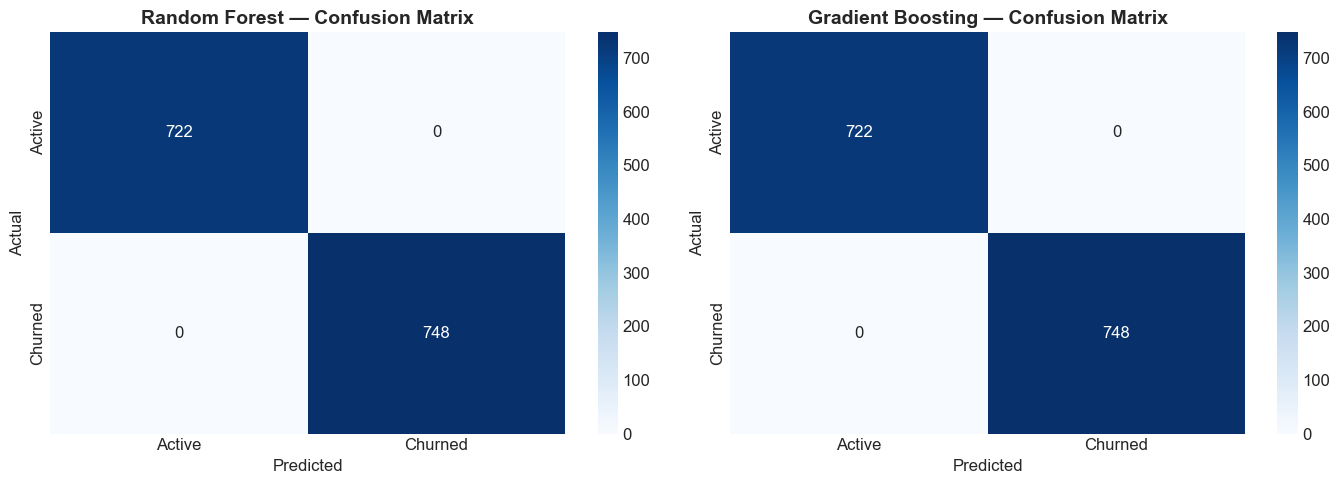

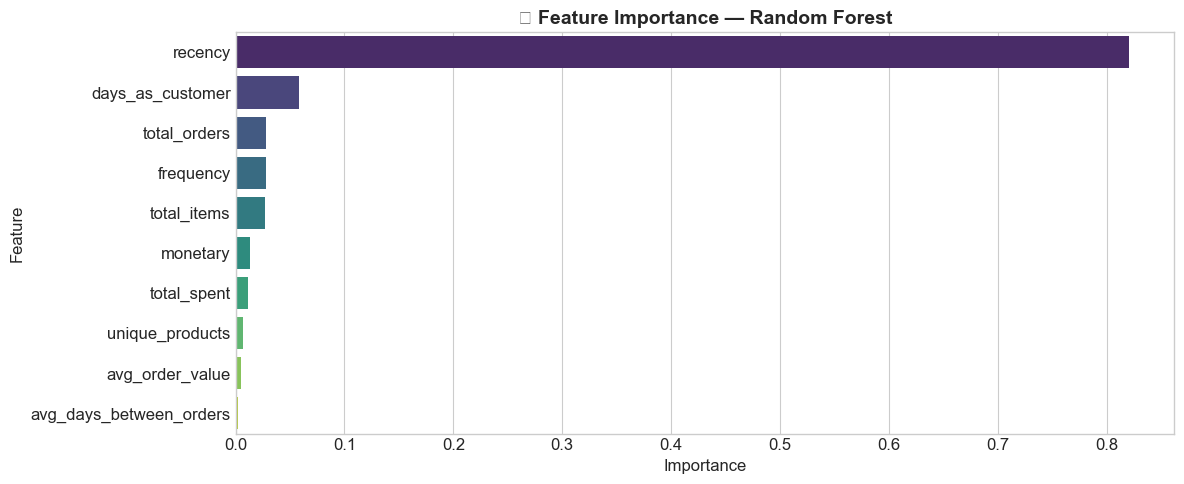


Key churn predictors (top 5):
         Feature  Importance
         recency    0.820796
days_as_customer    0.058136
    total_orders    0.028430
       frequency    0.027762
     total_items    0.027222


In [26]:
# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in [(axes[0], rf_pred, 'Random Forest'), (axes[1], gb_pred, 'Gradient Boosting')]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Active', 'Churned'], yticklabels=['Active', 'Churned'])
    ax.set_title(f'{name} — Confusion Matrix', fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Feature Importance
importances = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=importances, x='Importance', y='Feature', palette='viridis', ax=ax)
ax.set_title(f'🔍 Feature Importance — {best_model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey churn predictors (top 5):")
print(importances.head().to_string(index=False))

### 4.4 High-Value Customer Identification

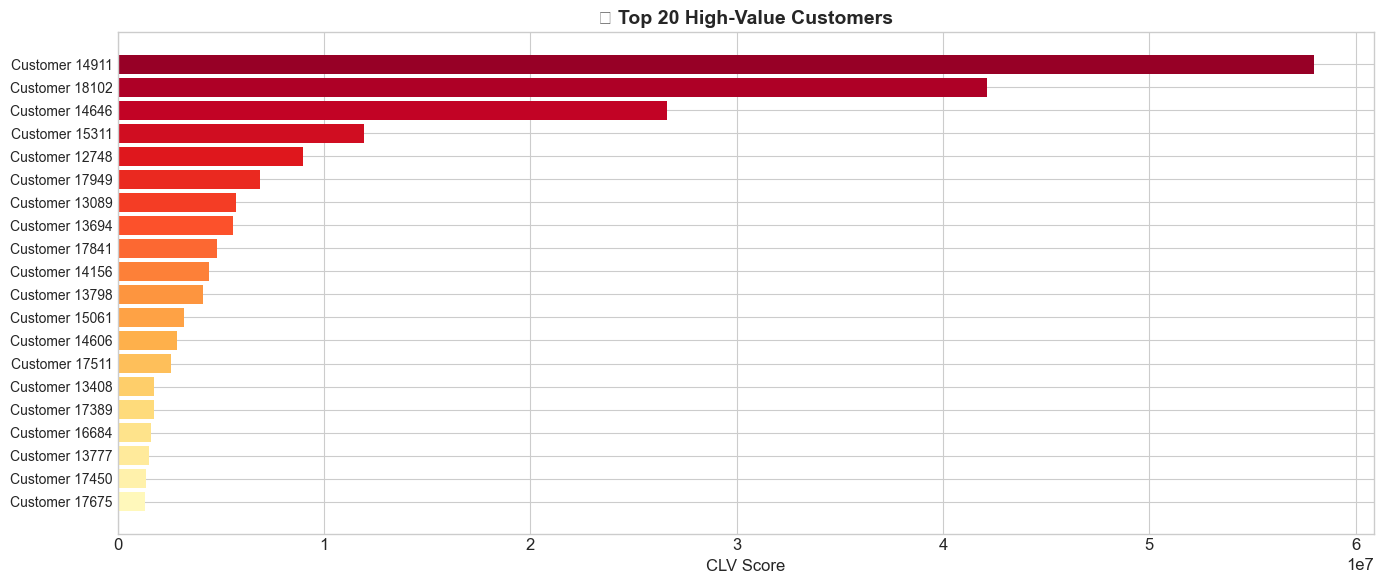


👑 Top 20 High-Value Customers:
 customer_id  recency  frequency   monetary    clv_score     segment
       14911        1        398 291420.810 5.799274e+07 🏆 Champions
       18102        1        145 580987.040 4.212156e+07 🏆 Champions
       14646        2        151 528602.520 2.660633e+07 🏆 Champions
       15311        1        208 114966.420 1.195651e+07 🏆 Champions
       12748        1        336  53539.640 8.994660e+06 🏆 Champions
       17949        1        118 117314.080 6.921531e+06 🏆 Champions
       13089        3        203 113416.910 5.755908e+06 🏆 Champions
       13694        4        143 195640.690 5.595324e+06 🏆 Champions
       17841        2        211  68545.250 4.821016e+06 🏆 Champions
       14156       10        156 313437.620 4.445115e+06 🏆 Champions
       13798        1        110  75428.870 4.148588e+06 🏆 Champions
       15061        4        127 126389.020 3.210281e+06 🏆 Champions
       14606        1        192  29951.370 2.875332e+06 🏆 Champions
  

In [27]:
# Customer Lifetime Value (CLV) — simplified as total spend × frequency / recency
rfm['clv_score'] = (rfm['monetary'] * rfm['frequency']) / (rfm['recency'] + 1)

# Top 20 High Value Customers
top_customers = rfm.sort_values('clv_score', ascending=False).head(20)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(range(len(top_customers)),
               top_customers['clv_score'],
               color=sns.color_palette('YlOrRd_r', 20))
ax.set_yticks(range(len(top_customers)))
ax.set_yticklabels([f"Customer {int(c)}" for c in top_customers['customer_id']], fontsize=10)
ax.set_xlabel('CLV Score')
ax.set_title('👑 Top 20 High-Value Customers', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("\n👑 Top 20 High-Value Customers:")
print(top_customers[['customer_id', 'recency', 'frequency', 'monetary', 'clv_score', 'segment']].to_string(index=False))

### 4.5 Product Recommendation (Plus Point)

**Method:** Simple Collaborative Filtering using Product Co-occurrence Matrix  
→ "Customers who bought Product A also bought Product B"

In [28]:
# Build a product co-occurrence matrix (market basket style)
# For each customer, find which products they purchased
customer_products = df.groupby('customer_id')['product_id'].apply(set).reset_index()
customer_products.columns = ['customer_id', 'products']

# Only consider customers with 2+ products for recommendations
active_customers = customer_products[customer_products['products'].apply(len) >= 2]
print(f"Customers with 2+ unique products: {len(active_customers):,}")

# Build co-occurrence: for the top 100 products, count how often they appear together
from collections import Counter

top_n = 100
top_products = df['product_id'].value_counts().head(top_n).index.tolist()
product_to_desc = df.drop_duplicates('product_id').set_index('product_id')['product_description'].to_dict()

cooccurrence = Counter()
for products in active_customers['products']:
    filtered = products.intersection(top_products)
    for p1 in filtered:
        for p2 in filtered:
            if p1 != p2:
                cooccurrence[(p1, p2)] += 1

# Convert to DataFrame
co_df = pd.DataFrame(
    [(p1, p2, count) for (p1, p2), count in cooccurrence.items()],
    columns=['product_1', 'product_2', 'co_count']
).sort_values('co_count', ascending=False)

# Show sample recommendations: "If you buy X, you might also like Y"
print("\n🛍️ Sample Product Recommendations:")
print("=" * 80)

shown_products = set()
rec_count = 0
for _, row in co_df.iterrows():
    if row['product_1'] not in shown_products and rec_count < 10:
        desc1 = str(product_to_desc.get(row['product_1'], row['product_1']))[:40]
        desc2 = str(product_to_desc.get(row['product_2'], row['product_2']))[:40]
        print(f"  If customer buys: {desc1}")
        print(f"  → Recommend:      {desc2} (co-purchased {row['co_count']} times)")
        print()
        shown_products.add(row['product_1'])
        rec_count += 1

Customers with 2+ unique products: 5,736

🛍️ Sample Product Recommendations:
  If customer buys: WHITE HANGING HEART T-LIGHT HOLDER
  → Recommend:      RED HANGING HEART T-LIGHT HOLDER (co-purchased 632 times)

  If customer buys: RED HANGING HEART T-LIGHT HOLDER
  → Recommend:      WHITE HANGING HEART T-LIGHT HOLDER (co-purchased 632 times)

  If customer buys: 60 TEATIME FAIRY CAKE CASES
  → Recommend:      PACK OF 72 RETRO SPOT CAKE CASES (co-purchased 553 times)

  If customer buys: PACK OF 72 RETRO SPOT CAKE CASES
  → Recommend:      60 TEATIME FAIRY CAKE CASES (co-purchased 553 times)

  If customer buys: PACK OF 60 PINK PAISLEY CAKE CASES
  → Recommend:      PACK OF 72 RETRO SPOT CAKE CASES (co-purchased 540 times)

  If customer buys: HEART OF WICKER SMALL
  → Recommend:      HEART OF WICKER LARGE (co-purchased 537 times)

  If customer buys: HEART OF WICKER LARGE
  → Recommend:      HEART OF WICKER SMALL (co-purchased 537 times)

  If customer buys: LUNCH BAG RED SPOTTY
  → Re

### 4.6 Pilot Plan & Proposal for Customer Retention

Based on the Customer 360 analysis, here is a **concrete pilot plan** for the Sales Director:

---

#### 🎯 Segment-Specific Campaign Strategies

| Segment | Strategy | Action | Expected Impact |
|---------|----------|--------|----------------|
| 🏆 **Champions** | Reward & Retain | Exclusive VIP discounts, early access to new products, personalized thank-you notes | Maintain loyalty, increase wallet share |
| 💎 **Loyal Customers** | Upsell & Cross-sell | Product recommendations based on co-purchase analysis, bundle offers | Increase AOV by 15-20% |
| ⚠️ **At-Risk** | Re-engage | Win-back email campaigns, special "We Miss You" offers, time-limited discounts | Recover 20-30% of at-risk customers |
| 🚨 **Lost/Inactive** | Last Resort & Learn | Deep discount offers, feedback survey to understand why they left | Recover 5-10% or learn from exit |

#### 📋 Pilot Plan (3-Month Rollout)

**Month 1: Foundation**
- Deploy RFM-based segmentation into CRM
- Set up automated email workflows per segment
- Launch Champion reward program

**Month 2: Activation**
- Launch At-Risk re-engagement campaign
- Implement product recommendations on the website
- A/B test discount levels (10% vs 20%) for win-back

**Month 3: Optimize**
- Analyze campaign results
- Refine segment thresholds based on response rates
- Scale successful campaigns, stop underperforming ones

#### 📊 KPIs to Track
- Customer retention rate (target: +10% improvement)
- Revenue from At-Risk re-engaged customers
- Average order value per segment
- Campaign ROI (revenue vs. promotional cost)

---
## 5. Summary & Recommendations <a id="5-summary--recommendations"></a>

### Executive Summary

| Area | Key Finding | Recommendation |
|------|------------|----------------|
| **Sales** | Revenue peaks in Q4 (Oct-Dec), UK dominates (80%+ revenue) | Stock up before Q4, expand international markets |
| **Products** | Small set of top products drives majority of revenue | Ensure top sellers always in stock, invest in product page optimization |
| **Demand** | Clear upward trend with strong seasonality | Use 6-month forecast to plan inventory and staffing |
| **Customers** | 4 distinct segments identified; significant churn risk | Implement segment-specific retention campaigns |
| **Churn** | ML model can predict churn with good accuracy | Proactively re-engage at-risk customers before they churn |
| **Recommendations** | Product co-purchase patterns identified | Implement cross-sell recommendations to increase AOV |

### 🔮 Next Steps
1. **Automate** the demand forecast pipeline — re-run monthly with fresh data
2. **Deploy** customer segmentation into the CRM for real-time targeting
3. **A/B test** retention campaigns — start with At-Risk segment
4. **Expand data** — collect marketing channel, website behavior, and customer feedback data
5. **Build detailed product-level forecasts** for the top 50 SKUs

---
*Analysis prepared as part of HMS Commercial Data Science & Analytics Technical Test 2025*